# Logistic Regression

## Outline

1. Introduction
2. Logistic Regression
3. Decision Boundary
4. Cost Function
5. Gradient Descent
6. Model Training and Prediction
7. Closing Remarks

## 1. Introduction

So far, we have discussed regression tasks that map features to a continuous target. For example, in the univariate linear regression notebook, our model learned to map study hours to exam scores.

Another category of machine learning tasks is classification. Classification models also take features as input, but instead of predicting a continuous value, they assign an example to a category.

In this notebook, we will discuss binary classification using logistic regression. Binary classification assigns each example to either the positive class, represented by 1, or the negative class, represented by 0.

You might think that we could use linear regression and apply a threshold to its continuous predictions. This is a reasonable first idea, but linear regression is not well suited for binary classification. Outliers can strongly affect the fitted regression line and therefore shift the resulting decision boundary. In addition, linear regression predictions are not restricted to the range from 0 to 1. Logistic regression addresses these problems and is specifically designed for binary classification.

> **Note**
>
> Throughout this notebook, we will refer to the implementation of logistic regression. The complete implementation can be found in the `src/ml_from_scratch` directory.
>
> If you are interested in the behavior of the individual functions, you may also want to explore the unit tests in the `tests` directory. Besides verifying correctness, they provide additional examples of how the implementation is intended to be used.

Run the code cell below to load the required dependencies and generate the dataset used throughout this notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils.helpers import (
    generate_logistic_regression_dataset,
)

from utils.plotting import (
    plot_binary_classes,
    plot_sigmoid_function,
    plot_decision_boundary,
)

from ml_from_scratch.logistic_regression import (
    sigmoid,
    fit,
)

X, y = generate_logistic_regression_dataset()

The dataset follows the same student-performance theme as the previous notebooks. It contains $m = 40$ training examples with two features:

- $x_{1}$: study hours (continuous)
- $x_{2}$: completed practice tests (discrete)

This time, the target $y$ is binary:

- $y = 1$: exam passed
- $y = 0$: exam failed

Before moving on to the next chapter, run the following code cell to visualize the dataset and examine how the two classes are distributed.

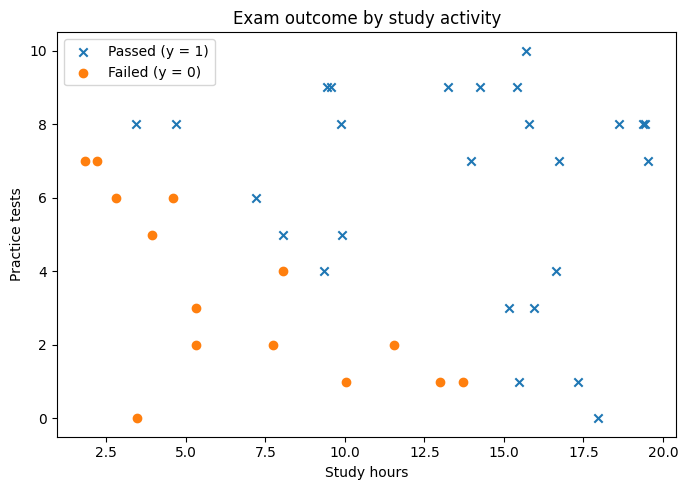

In [2]:
plot_binary_classes(X, y)

plt.show()

Study hours range from 1 to 20, while the number of completed practice tests ranges from 0 to 10. Of the 40 students, 27 passed the exam and 13 failed.

## 2. Logistic Regression

In contrast to the unrestricted outputs of linear regression, logistic regression produces values between 0 and 1. These values can be interpreted as the estimated probabilities that an example belongs to the positive class, represented by $y = 1$.

The function used to restrict the model output to this range is the sigmoid function. In the next code cell, we will plot the sigmoid function using 200 $z$-values generated with NumPy's `linspace` function.

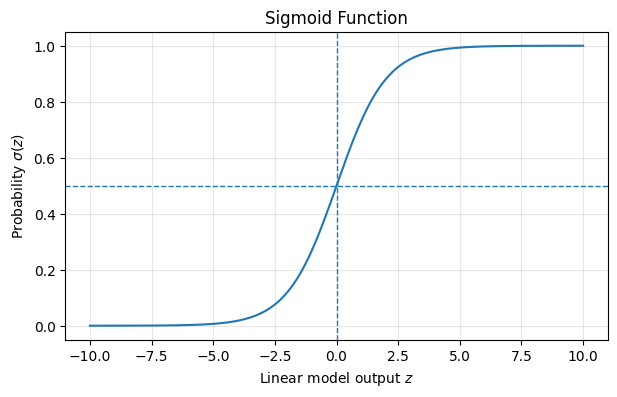

In [3]:
z = np.linspace(-10, 10, 200)
probabilities = sigmoid(z)

plot_sigmoid_function(z, probabilities)

plt.show()


As you can see the sigmoid function has an S-shaped curve. It is defined as

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The denominator contains the exponential term $e^{-z}$, where Euler's number $e$ is the base and $-z$ is the exponent. In the Python implementation of the sigmoid function, this term is computed using NumPy's `np.exp(-z)`. The function works element-wise, allowing it to process either a single $z$-value or an array of values.

In practice, $z$ is first computed as a linear combination of the input features plus a bias term:

$$
z = \mathbf{w} \cdot \mathbf{x} + b.
$$

Here, $\mathbf{w} \cdot \mathbf{x}$ denotes the dot product between the weight vector and the feature vector.

The result is then passed to the sigmoid function:

$$
f_{\mathbf{w},b}(\mathbf{x}) = \sigma(\mathbf{w} \cdot \mathbf{x} + b).
$$

Logistic regression therefore performs the calculation in two steps. First, it computes the linear model output $z$. It then applies the sigmoid function to transform this value into an estimated probability.

To make this calculation more concrete, consider a student who studied for 10 hours and completed 5 practice tests. The feature vector is therefore

$$
\mathbf{x}
=
\begin{bmatrix}
10 \\
5
\end{bmatrix}.
$$

For illustration, assume that the model parameters are

$$
\mathbf{w}
=
\begin{bmatrix}
0.5 \\
0.9
\end{bmatrix}
\qquad \text{and} \qquad
b = -8.
$$

The linear model output is then

$$
\begin{aligned}
z
&= \mathbf{w} \cdot \mathbf{x} + b \\
&= 0.5 \cdot 10 + 0.9 \cdot 5 - 8 \\
&= 1.5.
\end{aligned}
$$

This value is then passed to the sigmoid function:

$$
\begin{aligned}
\sigma(1.5)
&= \frac{1}{1 + e^{-1.5}} \\
&\approx 0.818.
\end{aligned}
$$

The model therefore estimates a probability of approximately 81.8% that this student belongs to the positive class and passes the exam. In more formal terms, we can write

$$
P(y = 1 \mid \mathbf{x}) \approx 0.818,
$$

where the vertical bar is read as “given.” The expression therefore means: “The probability that $y = 1$, given the feature vector $\mathbf{x}$.”

You might wonder whether $z = \mathbf{w} \cdot \mathbf{x} + b$ is itself a linear regression model because the equation looks familiar. However, $z$ is simply a linear combination of the input features plus a bias term. The same linear expression is used in linear regression, but it can also serve as one component of other models. In logistic regression, the linear output is passed through the sigmoid function instead of being used directly as the prediction.

Besides its S-shape, the plot shows that the sigmoid function is bounded between 0 and 1. The endpoints are not included, meaning that the output approaches but never mathematically reaches either value.

When $z$ is very large and negative, the exponent $-z$ becomes very large and positive. Therefore, $e^{-z}$ and the denominator become very large:

$$
\sigma(z) = \frac{1}{1 + e^{-z}} \approx 0.
$$

On the other hand, when $z$ is very large and positive, $-z$ becomes very negative and $e^{-z}$ approaches 0. The denominator therefore approaches 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}} \approx 1.
$$

Another important point occurs at $z = 0$. Since $e^{0} = 1$, we obtain

$$
\sigma(0) = \frac{1}{1 + 1} = \frac{1}{2}.
$$

The sigmoid function therefore returns exactly $0.5$ when the linear model output is zero.

One important fact is that the sigmoid output is not yet a binary class prediction. A probability threshold is still required to assign an example to either the negative class $y = 0$ or the positive class $y = 1$. We will discuss this decision rule in the next chapter.

## 3. Decision Boundary

A common decision threshold for binary classification is an estimated probability of $0.5$. Since the sigmoid function returns exactly $0.5$ at $z = 0$, we can directly relate this threshold to the linear model output:

$$
\sigma(z) \geq 0.5 \quad \Longleftrightarrow \quad z \geq 0.
$$

This means that examples with $z \geq 0$ are assigned to the positive class $y = 1$, while examples with $z < 0$ are assigned to the negative class $y = 0$.

You can see this decision rule implemented in the `predict` function. The function also allows you to specify a different probability threshold if the problem at hand is better suited for a higher or lower value.

To make it more intuitive how the decision boundary separates the feature space into the two classes, we will plot it together with our dataset in the next code cell.

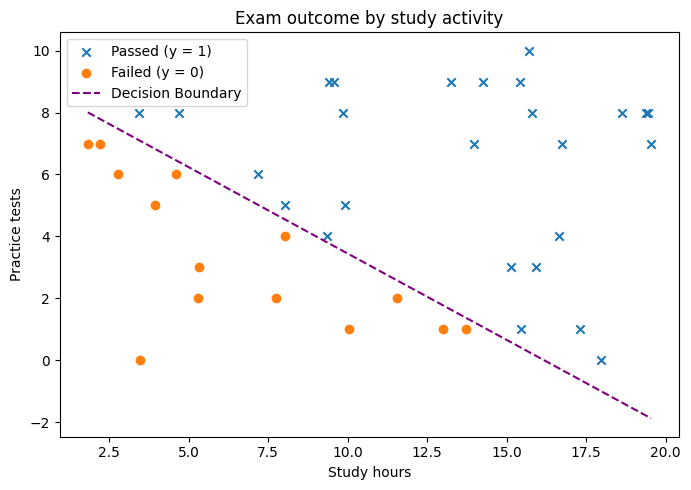

In [4]:
plot_binary_classes(X, y)

w, b = fit(X, y, alpha=0.3, iterations=10000)

x1_values = np.array([
    X[:, 0].min(),
    X[:, 0].max()
])
x2_values = -(w[0] * x1_values + b) / w[1]

plot_decision_boundary(x1_values, x2_values)

plt.legend()
plt.show()

Let me explain what we did in the previous code cell to visualize the decision boundary.

First, we used the `fit` function to train the model on the training data and obtain the learned parameter values for $\mathbf{w}$ and $b$.

To draw the linear decision boundary, we only need two points. We use the minimum and maximum values of $x_1$ from the feature matrix as the horizontal coordinates of these points.

Remember that we use a probability threshold of $0.5$. Since the sigmoid function returns exactly $0.5$ when $z = 0$, the decision boundary satisfies

$$
w_1x_1 + w_2x_2 + b = 0.
$$

To calculate the corresponding $x_2$-values for the two selected $x_1$-values, we rearrange the equation:

$$
\begin{aligned}
w_1x_1 + w_2x_2 + b &= 0 \\
w_2x_2 &= -(w_1x_1 + b) \\
x_2 &= -\frac{w_1x_1 + b}{w_2}.
\end{aligned}
$$

This gives us two points on the decision boundary, which can be connected to form the straight line separating the two classes. Although the number of completed practice tests is discrete in our dataset, the calculated $x_2$-values of the decision boundary are continuous. These values do not represent actual students; they describe the mathematical boundary in the feature space.

The reason why we only had to calculate two points to draw the decision boundary is that, with the original features and a linear model, the decision boundary is a straight line. By adding polynomial features such as $x_1^2$, $x_2^2$, or $x_1x_2$, logistic regression can also represent non-linear decision boundaries such as circles, ellipses, or more complex shapes.

We now know how a probability threshold can be used to convert the sigmoid output into a binary class prediction and how this decision rule appears as a boundary in the feature space.

The next step will be to look more closely at the cost function for logistic regression. As in linear regression, the model is trained using gradient descent, which minimizes a cost function. Logistic regression, however, requires a different cost function from the squared-error cost we used for linear regression.

## 4. Cost Function

If we use the squared-error cost from linear regression together with the sigmoid function, the resulting cost function can become non-convex. This makes optimization with Gradient Descent more difficult because it may converge to a local minimum instead of the global minimum.

For logistic regression, we therefore use a logarithmic loss that results in a convex cost function.

Let's first look at the loss for a single training example:

$$
L(f_{\mathbf{w},b}(\mathbf{x}), y)
=
-y \log(f_{\mathbf{w},b}(\mathbf{x}))
-
(1-y)\log(1-f_{\mathbf{w},b}(\mathbf{x})).
$$

We know that logistic regression is a binary classification problem, so the target label for each training example can only be $0$ or $1$.

If $y = 1$, the second term becomes zero:

$$
L(f_{\mathbf{w},b}(\mathbf{x}), 1)
=
-\log(f_{\mathbf{w},b}(\mathbf{x})).
$$

If $y = 0$, the first term becomes zero:

$$
L(f_{\mathbf{w},b}(\mathbf{x}), 0)
=
-\log(1-f_{\mathbf{w},b}(\mathbf{x})).
$$

Instead of defining these two cases separately, we combine them into the single loss expression shown above.

The logistic regression cost function is then the average loss over all $m$ training examples:

$$
J(\mathbf{w}, b)
=
\frac{1}{m}
\sum_{i=1}^{m}
L(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}).
$$

This cost function is commonly used to train logistic regression models and can be derived from the statistical principle of maximum likelihood estimation.

In the next chapter, we will take a closer look at the mathematics behind the optimization process and derive the gradients used in Gradient Descent.

## 5. Gradient Descent

In the previous chapter, we introduced the logistic cost function that measures how well the model fits the training data. To train the model, we now need to find values for $\mathbf{w}$ and $b$ that minimize this cost.

For this optimization, we can once again use Gradient Descent. The general idea remains the same as in linear regression: we repeatedly calculate the gradients of the cost function and update the model parameters in the opposite direction.

The simultaneous update steps are therefore already familiar:

$$
w_j := w_j - \alpha \frac{\partial J}{\partial w_j},
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}.
$$

What is particularly interesting is that the gradients themselves have the same general form as the ones we encountered in linear regression:

$$
\frac{\partial J}{\partial w_j}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}
\right)
x_j^{(i)},
$$

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}
\right).
$$

This may seem surprising because both the model and the cost function have changed.

So why do the gradients still have such a familiar form?

To answer this question, we will derive them step by step from the logistic cost function. The derivation takes some time, so if you are mainly interested in the general concepts, you can skip this mathematical section. However, I encourage you to follow it because it is also a useful opportunity to practice partial derivatives and see how such a task can be approached systematically.

Below is the complete logistic regression cost function again as a reference:

$$
J(\mathbf{w}, b)
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
-y^{(i)}
\log(f_{\mathbf{w},b}(\mathbf{x}^{(i)}))
-
(1-y^{(i)})
\log(1-f_{\mathbf{w},b}(\mathbf{x}^{(i)}))
\right).
$$

For a single training example, we define

$$
z^{(i)}
=
\mathbf{w} \cdot \mathbf{x}^{(i)} + b
$$

and therefore

$$
f_{\mathbf{w},b}(\mathbf{x}^{(i)})
=
\sigma(z^{(i)}).
$$

### 1. Derivative of the Sigmoid Function


Before differentiating the cost function, we first need the derivative of the sigmoid function.

To make the sigmoid function easier to differentiate, we rewrite it as

$$
\sigma(z)
=
\frac{1}{1+e^{-z}}
=
(1+e^{-z})^{-1}.
$$

Now we differentiate with respect to $z$:

$$
\begin{aligned}
\sigma'(z)
&=
\frac{d}{dz}(1+e^{-z})^{-1} \\
&=
-(1+e^{-z})^{-2}(-e^{-z}) \\
&=
\frac{e^{-z}}{(1+e^{-z})^2}.
\end{aligned}
$$

For convenience, we can express this derivative in a more compact form.

Since

$$
\sigma(z)
=
\frac{1}{1+e^{-z}},
$$

it also follows that

$$
\begin{aligned}
1-\sigma(z)
&=
1-\frac{1}{1+e^{-z}} \\
&=
\frac{e^{-z}}{1+e^{-z}}.
\end{aligned}
$$

Multiplying both expressions gives

$$
\begin{aligned}
\sigma(z)(1-\sigma(z))
&=
\frac{1}{1+e^{-z}}
\cdot
\frac{e^{-z}}{1+e^{-z}} \\
&=
\frac{e^{-z}}{(1+e^{-z})^2}.
\end{aligned}
$$

This is exactly the expression we obtained for the derivative of the sigmoid function. Therefore, we obtain the useful identity

$$
\boxed{
\sigma'(z)
=
\sigma(z)(1-\sigma(z))
}.
$$

### 2. Partial Derivative with Respect to the Weights

We are now ready to calculate the partial derivative of the cost function with respect to $\mathbf{w}$.

To make the calculation more manageable, we first consider the loss of a single training example and split it into its two terms:

$$
-y^{(i)}\log(\sigma(z^{(i)}))
$$

and

$$
-(1-y^{(i)})\log(1-\sigma(z^{(i)})).
$$

We start with the first term. Since $-y^{(i)}$ is constant with respect to $\mathbf{w}$, we temporarily leave it aside and first differentiate

$$
\log(\sigma(z^{(i)})).
$$

Applying the chain rule gives

$$
\frac{\partial}{\partial \mathbf{w}}
\log(\sigma(z^{(i)}))
=
\frac{1}{\sigma(z^{(i)})}
\cdot
\sigma'(z^{(i)})
\cdot
\frac{\partial z^{(i)}}{\partial \mathbf{w}}.
$$

We know that

$$
\sigma'(z^{(i)})
=
\sigma(z^{(i)})(1-\sigma(z^{(i)}))
$$

and

$$
\frac{\partial z^{(i)}}{\partial \mathbf{w}}
=
\mathbf{x}^{(i)}.
$$

Substituting both expressions gives

$$
\frac{1}{\sigma(z^{(i)})}
\cdot
\sigma(z^{(i)})(1-\sigma(z^{(i)}))
\cdot
\mathbf{x}^{(i)}.
$$

The term $\sigma(z^{(i)})$ cancels out:

$$
(1-\sigma(z^{(i)}))\mathbf{x}^{(i)}.
$$

After reintroducing the coefficient $-y^{(i)}$, we obtain

$$
\boxed{
-y^{(i)}
\frac{\partial}{\partial \mathbf{w}}
\log(\sigma(z^{(i)}))
=
-y^{(i)}
(1-\sigma(z^{(i)}))
\mathbf{x}^{(i)}
}.
$$

For the second term, we again temporarily leave the coefficient $-(1-y^{(i)})$ aside.

We start by applying the chain rule:

$$
\frac{\partial}{\partial \mathbf{w}}
\log(1-\sigma(z^{(i)}))
=
\frac{1}{1-\sigma(z^{(i)})}
\cdot
\frac{\partial}{\partial \mathbf{w}}
(1-\sigma(z^{(i)})).
$$

Because $\sigma(z^{(i)})$ is itself a nested function, we apply the chain rule once more:

$$
\frac{\partial}{\partial \mathbf{w}}
(1-\sigma(z^{(i)}))
=
-\sigma'(z^{(i)})
\cdot
\frac{\partial z^{(i)}}{\partial \mathbf{w}}.
$$

Thus,

$$
\frac{\partial}{\partial \mathbf{w}}
\log(1-\sigma(z^{(i)}))
=
\frac{1}{1-\sigma(z^{(i)})}
\cdot
\left(-\sigma'(z^{(i)})\right)
\cdot
\frac{\partial z^{(i)}}{\partial \mathbf{w}}.
$$

Using

$$
\sigma'(z^{(i)})
=
\sigma(z^{(i)})(1-\sigma(z^{(i)}))
$$

and

$$
\frac{\partial z^{(i)}}{\partial \mathbf{w}}
=
\mathbf{x}^{(i)},
$$

we obtain

$$
\frac{1}{1-\sigma(z^{(i)})}
\cdot
\left[
-\sigma(z^{(i)})(1-\sigma(z^{(i)}))
\right]
\cdot
\mathbf{x}^{(i)}.
$$

The term $1-\sigma(z^{(i)})$ cancels out:

$$
-\sigma(z^{(i)})\mathbf{x}^{(i)}.
$$

After multiplying by the coefficient $-(1-y^{(i)})$, the two negative signs cancel:

$$
\boxed{
-(1-y^{(i)})
\frac{\partial}{\partial \mathbf{w}}
\log(1-\sigma(z^{(i)}))
=
(1-y^{(i)})
\sigma(z^{(i)})
\mathbf{x}^{(i)}
}.
$$

We can now combine both parts and factor out $\mathbf{x}^{(i)}$:

$$
\frac{\partial J}{\partial \mathbf{w}}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left[
-y^{(i)}(1-\sigma(z^{(i)}))
+
(1-y^{(i)})\sigma(z^{(i)})
\right]
\mathbf{x}^{(i)}.
$$

Now it gets interesting. Expanding the expression inside the brackets gives

$$
-y^{(i)}
+
y^{(i)}\sigma(z^{(i)})
+
\sigma(z^{(i)})
-
y^{(i)}\sigma(z^{(i)}).
$$

The terms

$$
+y^{(i)}\sigma(z^{(i)})
\quad \text{and} \quad
-y^{(i)}\sigma(z^{(i)})
$$

cancel out, leaving

$$
\sigma(z^{(i)})-y^{(i)}.
$$

Therefore, we finally obtain the gradient with respect to the weight vector:

$$
\boxed{
\frac{\partial J}{\partial \mathbf{w}}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
\sigma(z^{(i)})-y^{(i)}
\right)
\mathbf{x}^{(i)}
}.
$$

This has the same general structure as the gradient we encountered in linear regression: the difference between the model prediction and the target is multiplied by the input features.

### 3. Partial Derivative with Respect to the Bias

The derivative with respect to $b$ follows the same steps. The important difference is that

$$
z^{(i)}
=
\mathbf{w} \cdot \mathbf{x}^{(i)} + b
$$

has the derivative

$$
\frac{\partial z^{(i)}}{\partial b}
=
1.
$$

For the first term of the loss, we therefore obtain

$$
\begin{aligned}
-y^{(i)}
\frac{\partial}{\partial b}
\log(\sigma(z^{(i)}))
&=
-y^{(i)}
\frac{1}{\sigma(z^{(i)})}
\sigma'(z^{(i)})
\frac{\partial z^{(i)}}{\partial b} \\
&=
-y^{(i)}
(1-\sigma(z^{(i)})).
\end{aligned}
$$

For the second term,

$$
\begin{aligned}
-(1-y^{(i)})
\frac{\partial}{\partial b}
\log(1-\sigma(z^{(i)}))
&=
(1-y^{(i)})
\sigma(z^{(i)}).
\end{aligned}
$$

Combining both expressions gives

$$
-y^{(i)}(1-\sigma(z^{(i)}))
+
(1-y^{(i)})\sigma(z^{(i)}).
$$

Just as before, this simplifies to

$$
\sigma(z^{(i)})-y^{(i)}.
$$

Averaging over all $m$ training examples therefore gives

$$
\boxed{
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
\sigma(z^{(i)})-y^{(i)}
\right)
}.
$$

We have now derived both gradients required for Gradient Descent. Despite using a different model and cost function, their general structure is the same as in linear regression. The crucial difference lies in the prediction itself: for logistic regression, the prediction is obtained by applying the sigmoid function to the linear model output.

In the next chapter, we will train the logistic regression model on our dataset using Gradient Descent.

## 6. Model Training and Prediction

## 7. Closing Remarks